In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

#Case specific parameters. Change to evaluate a different emulator or a different pipeline
testset_data = '../data/data/data/gas_tri_256/datatest.npy'
results_emu = './results_emu/vr_256/1980.npy'
testset_params = '../data/data/data/gas_tri_256/testpara.csv'
component_sim = 2
component_emu = 0
resolution = 256

#load the data and parameters of the test set
testset = np.load(testset_data)[:,[2,1],::-1] #loads data of the testset with the correct sign
testparams = pd.read_csv(testset_params, index_col=0)
testset_cmaps = np.load('cmaps_from_simulations_testset_parfile_R261_phi0.99_hd163296like2.npy')[:-2]
testparams

,InvStokes1,Alpha,AspectRatio,FlaringIndex,PlanetMass,SigmaSlope,nx,rout,ny
0,154.881662,0.001479,0.04435,0.09975,0.000327,0.6995,708.0,3,228.0
1,32.359366,0.000234,0.03525,0.25025,0.002786,1.0005,891.0,3,287.0
2,37.153523,0.002818,0.08635,0.04375,0.005188,0.5875,600.0,5,242.0
3,107.151931,0.001175,0.06045,0.01575,0.000031,0.5315,600.0,3,193.0
4,588.843655,0.006166,0.08565,0.30275,0.000610,1.1055,600.0,3,193.0
...,...,...,...,...,...,...,...,...,...
290,467.735141,0.000933,0.08915,0.23975,0.000010,0.9795,600.0,3,193.0
291,223.872114,0.003890,0.09895,0.34125,0.000027,1.1825,600.0,3,193.0
294,22.387211,0.001778,0.07235,0.30275,0.000164,1.1055,600.0,3,193.0
297,134.896288,0.008128,0.04155,0.09625,0.000124,0.6925,756.0,3,243.0


In [2]:
mses_cmaps = np.load('mse_varp_testset_cmaps_hd163296_corr3.npz', allow_pickle=True)

In [4]:
mses_cmaps['Alpha'].shape

(181, 2, 20, 105)

In [5]:
N = 20
grids = {'Alpha': np.logspace(-4,-2,N), 'PlanetMass': np.logspace(-5,-2,N), 'AspectRatio': np.linspace(0.03, 0.1,N)}


In [6]:
mses_cmaps['PlanetMass'].shape

(181, 2, 20, 105)

Text(0, 0.5, '#')

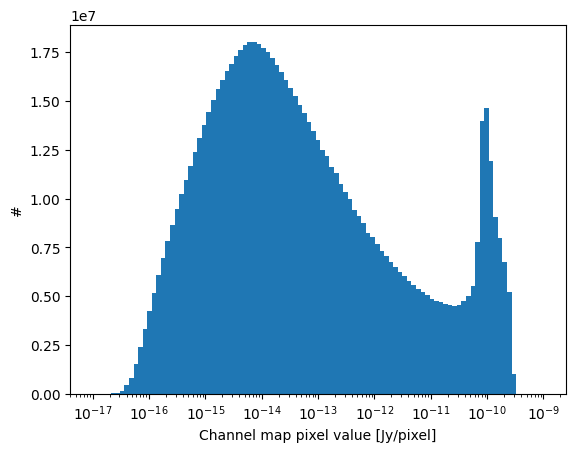

In [7]:
plt.hist(testset_cmaps.ravel(), bins=np.logspace(-17, -9, 100))
plt.xscale('log')
plt.xlabel('Channel map pixel value [Jy/pixel]')
plt.ylabel('#')

Text(0, 0.5, '#')

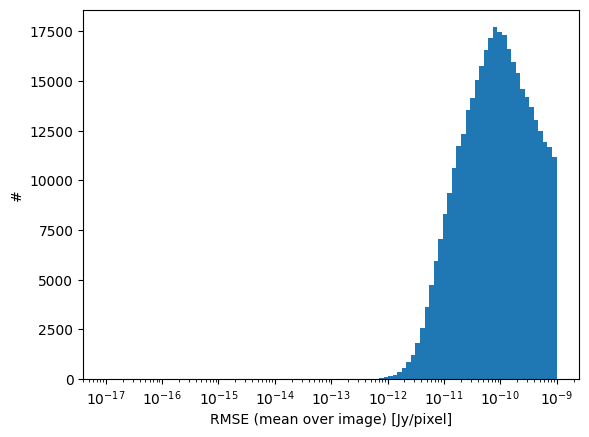

In [8]:
plt.hist(mses_cmaps['PlanetMass'].ravel()**0.5, bins=np.logspace(-17, -9, 100))
plt.xscale('log')
plt.xlabel('RMSE (mean over image) [Jy/pixel]')
plt.ylabel('#')

Text(0, 0.5, 'Sum of rmse across emulations [Jy/pixel]')

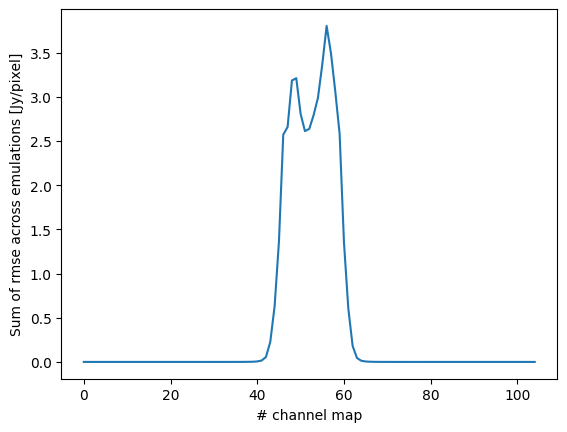

In [9]:
plt.plot((mses_cmaps['PlanetMass']**0.5).sum(axis=(0,1,2)).T)
#plt.ylim(1e-11,3e-10)
#plt.yscale('log')
plt.xlabel('# channel map')
plt.ylabel('Sum of rmse across emulations [Jy/pixel]')

In [10]:
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display

prop = 'PlanetMass'

def plot_i(i):
    plt.figure()
    plt.scatter(grids[prop], mses_cmaps[prop][i, 0].mean(axis=-1)**0.5)
    plt.axvline(testparams.iloc[i][prop])
    plt.xscale('log')
    plt.yscale('log')
    plt.xlabel(prop)
    plt.ylabel('RMSE')
    plt.show()

slider = widgets.IntSlider(
    value=21,
    min=0,
    max=len(testparams)-1,
    step=1,
    description='i'
)

widgets.interactive(plot_i, i=slider)


interactive(children=(IntSlider(value=21, description='i', max=232), Output()), _dom_classes=('widget-interact…

In [11]:
testparams['Mth'] = testparams['PlanetMass']/testparams['AspectRatio']**3

IndexError: index 228 is out of bounds for axis 0 with size 181

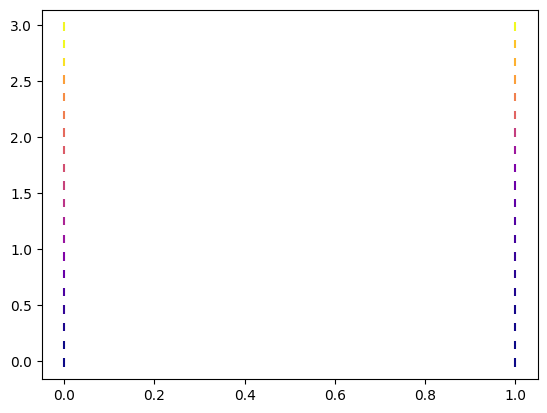

In [12]:
prop = 'PlanetMass'
sortindex = np.argsort(np.log10(testparams[:-2][prop]))
for j, i in enumerate(sortindex):
    plt.scatter(j*np.ones(20),
                np.log10(grids[prop])-np.log10(testparams.iloc[i][ prop]),
                c= np.log10(np.array(mses_cmaps[prop][i, 0].mean(axis=-1)**0.5, dtype=np.float32)),
                cmap='plasma',
                marker='|')
plt.gcf().set_size_inches(10, 5)
plt.axhline(0, color='red')
plt.xlim(0,231)
plt.xlabel('Reordered Id of testset simulation')
plt.ylabel('Emulation log$M_p/M_*$ - True log$M_p/M_*$')

Text(0, 0.5, 'Emulation log$M_p/M_*$ - True log$M_p/M_*$')

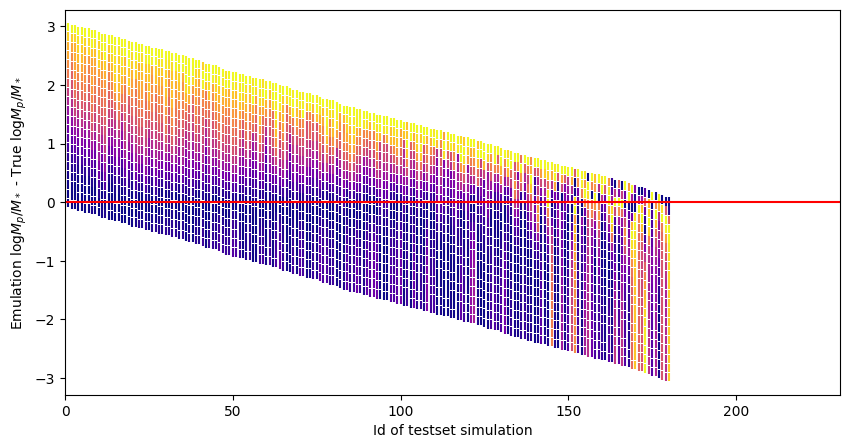

In [14]:
prop = 'PlanetMass' 
sortindex = np.argsort(np.log10(testparams[:181][prop]))
for j, i in enumerate(sortindex):
    plt.scatter(j*np.ones(20),
                np.log10(grids[prop])-np.log10(testparams.iloc[i][ prop]),
                c= np.log10(np.array(mses_cmaps[prop][i, 0, :, 56]**0.5, dtype=np.float32)),
                cmap='plasma',
                marker='|')
plt.gcf().set_size_inches(10, 5)
plt.axhline(0, color='red')
plt.xlim(0,231)
plt.xlabel('Id of testset simulation')
plt.ylabel('Emulation log$M_p/M_*$ - True log$M_p/M_*$')

In [15]:
sigmas_right = []
sigmas_left = []
sigmas = []

prop = 'PlanetMass'

for i in range(mses_cmaps['PlanetMass'].shape[0]):
    mses = np.array(mses_cmaps['PlanetMass'])[i, 0, :, :].sum(axis=-1)
    minimum = np.argmin(mses)
    N = np.min(mses)
    rm = minimum+1 if minimum<19 else 19
    lm = minimum-1 if minimum>0 else 0
    sigmas.append((1/((mses[rm]-2*mses[minimum]+mses[lm])/((-2+5)/20)**2/N))**0.5)
    if mses[rm] > mses[minimum]: 
        sigmas_right.append((1/((2*mses[rm]-2*mses[minimum])/((-2+5)/20)**2/N))**0.5)
    else:
        sigmas_right.append(np.log10(grids[prop][-1])-np.log10(grids[prop][minimum]))

    if mses[lm] > mses[minimum]:
        sigmas_left.append((1/((2*mses[lm]-2*mses[minimum])/((-2+5)/20)**2/N))**0.5)
    else:
        sigmas_left.append(-np.log10(grids[prop][0])+np.log10(grids[prop][minimum]))
        
sigmas = np.array(sigmas)
    #plt.scatter(np.log10(grids['PlanetMass'])-np.log10(testparams.iloc[i]['PlanetMass']), np.array(mse_varp_testset['PlanetMass'])[i, 0, :, 0])
    #plt.xscale('log')#plt.yscale('log')
mins = np.argmin(mses_cmaps['PlanetMass'][:, 0, :, :].mean(axis=-1), axis=1)
valmins = np.min(mses_cmaps['PlanetMass'][:, 0, :, :].mean(axis=-1), axis=1)


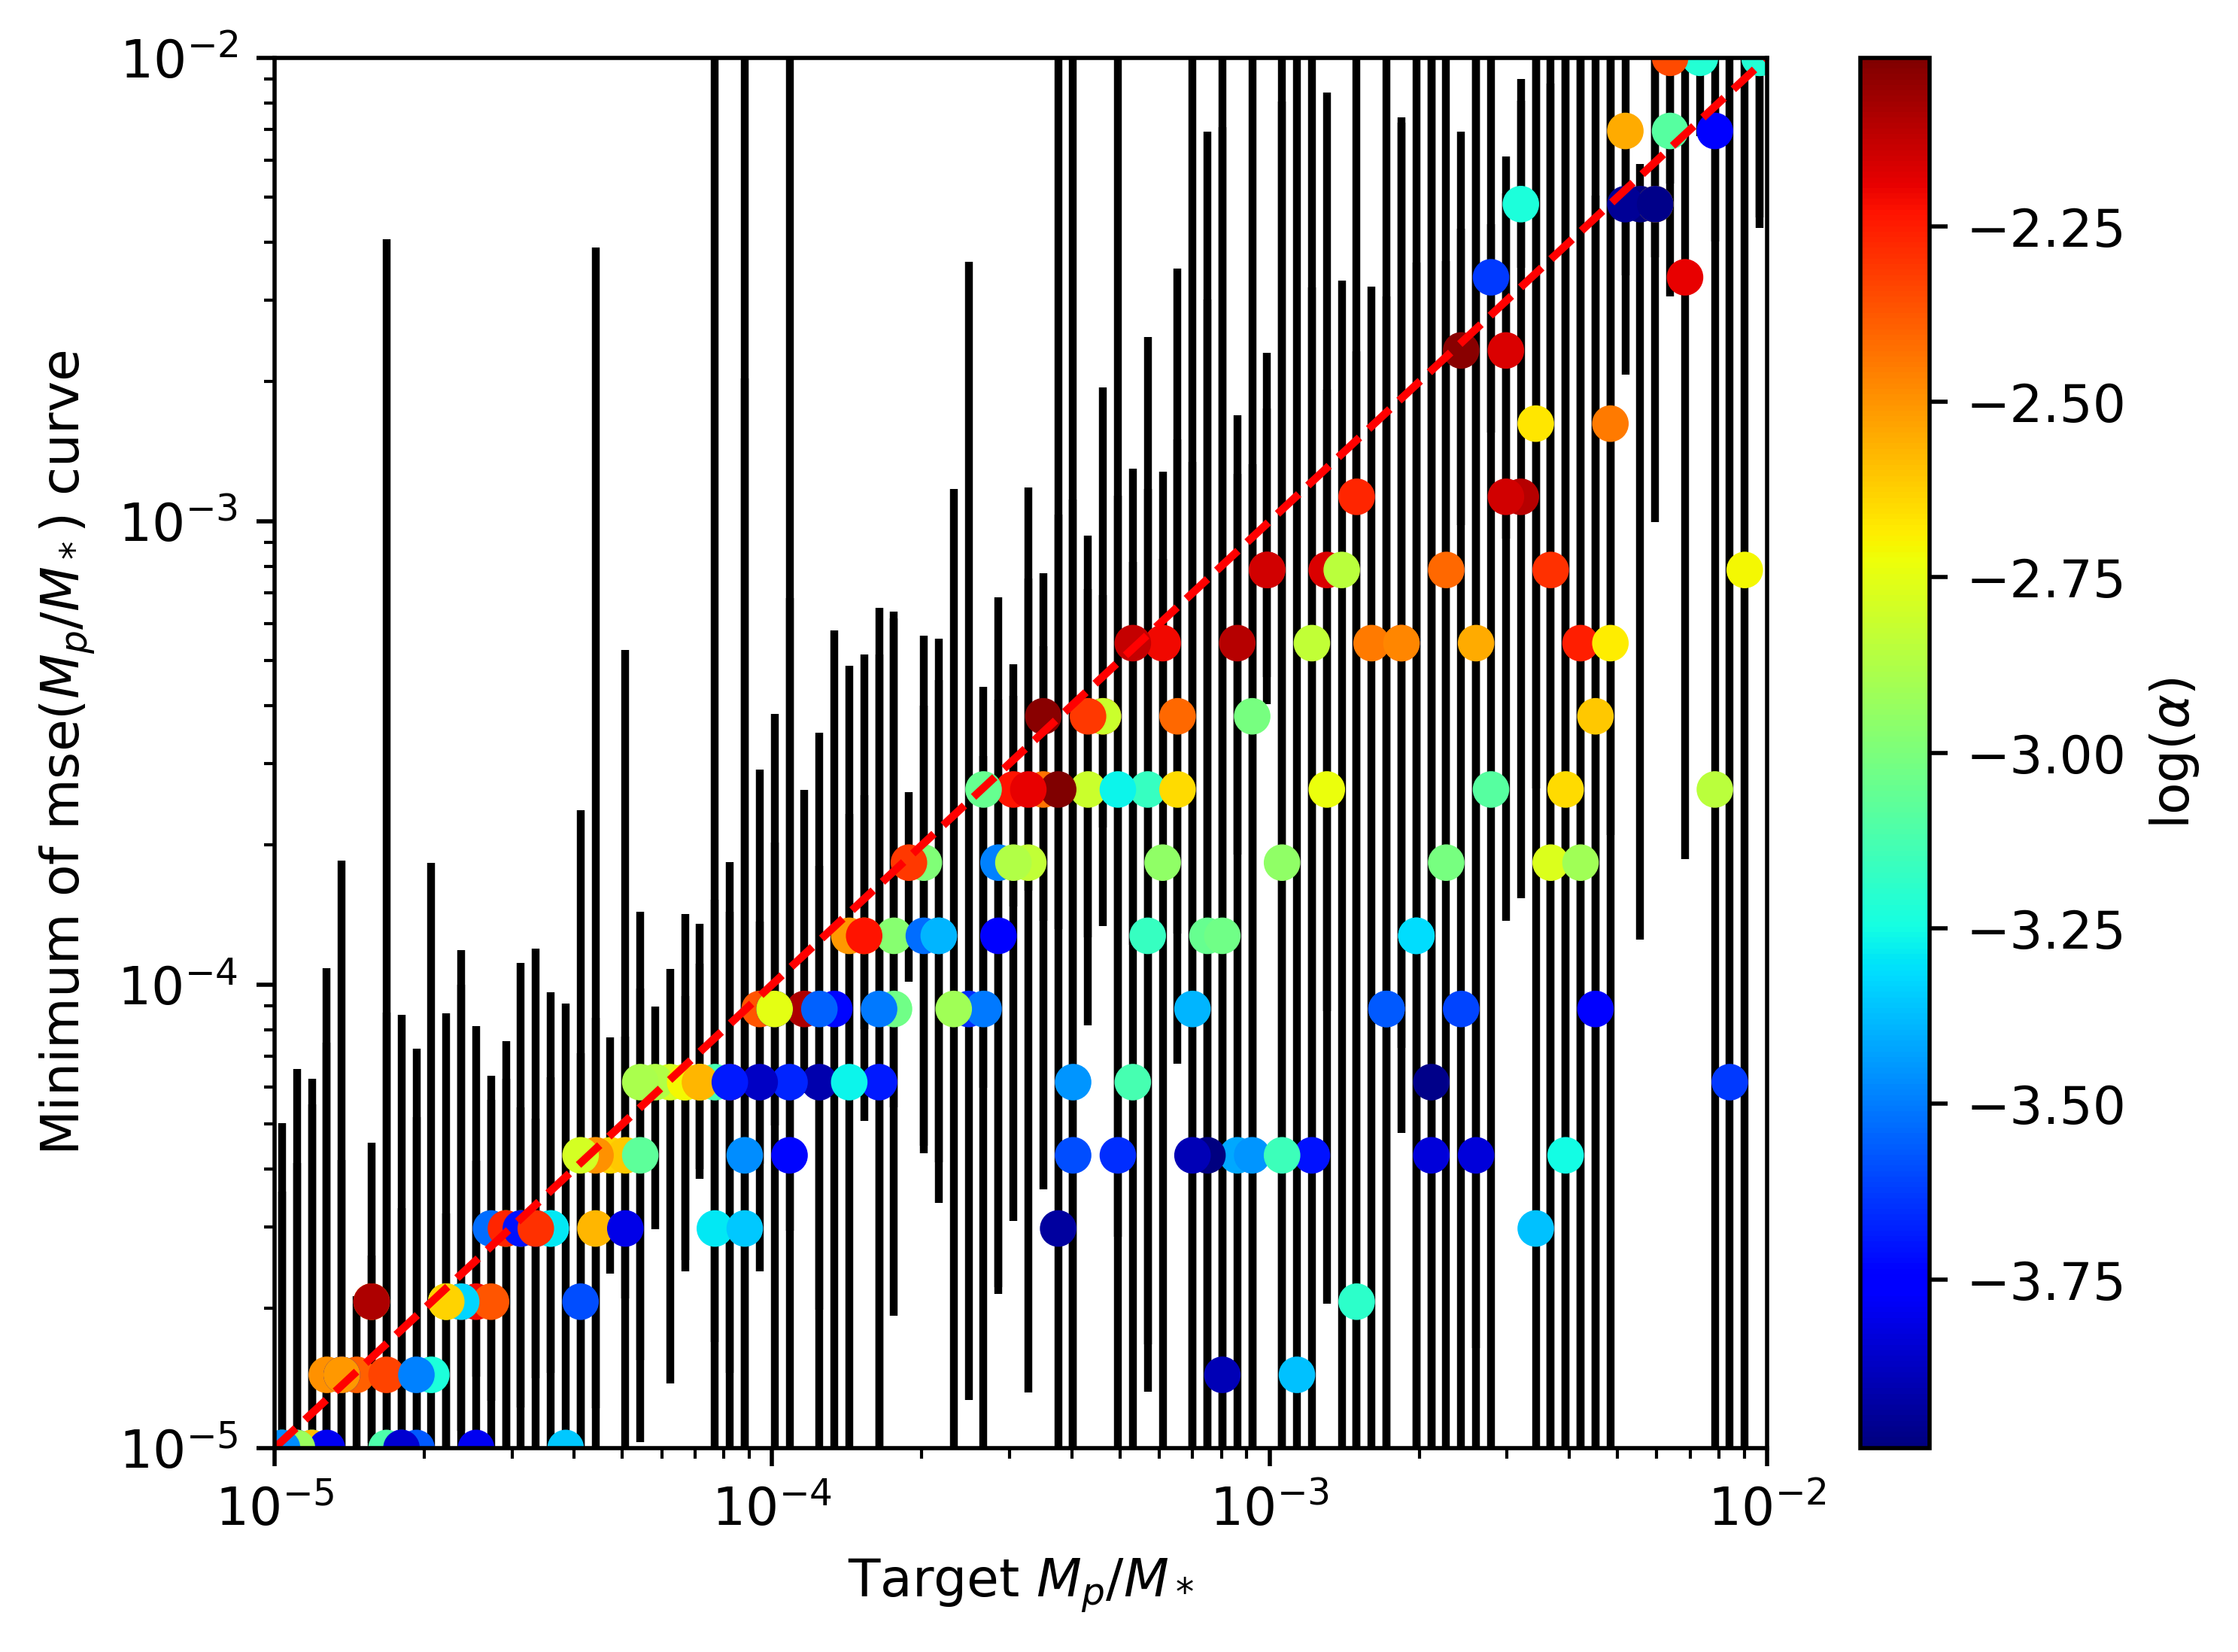

In [18]:
plt.xscale('log')
plt.yscale('log')

errs = (-10**(np.log10(grids['PlanetMass'][mins])-sigmas_left)+grids['PlanetMass'][mins], 10**(np.log10(grids['PlanetMass'][mins])+sigmas_right)-grids['PlanetMass'][mins])
plt.errorbar(testparams['PlanetMass'][:181], grids['PlanetMass'][mins], yerr=errs, fmt='.', color='black', zorder=-1)
plt.scatter(testparams['PlanetMass'][:181], grids['PlanetMass'][mins], c=np.log10(testparams[:181]['Alpha']), cmap='jet')
plt.colorbar(label='log($\\alpha$)')
plt.xlabel('Target $M_p/M_*$')
plt.ylabel('Minimum of mse($M_p/M_*$) curve')
plt.yscale('log')
plt.xlim(1e-5, 1e-2)
plt.ylim(1e-5, 1e-2)
plt.plot([1e-5, 1e-2], [1e-5, 1e-2], color='red', linestyle='dashed')
plt.gcf().set_dpi(500)

In [19]:
diff = (np.log10(testparams['PlanetMass'][:-2])-np.log10(grids['PlanetMass'][mins]))
diffs = diff
diffs[diff>0] = diffs/sigmas_right 
diffs[diff<0] = diffs/sigmas_left
plt.hist(diffs, bins=np.linspace(-1.5,1.5,20))
plt.xlabel('(True $M_p$ - Estimate $M_p$)/sigma')
#plt.yscale('log')
plt.gcf().set_dpi(500)

ValueError: operands could not be broadcast together with shapes (231,) (181,) 

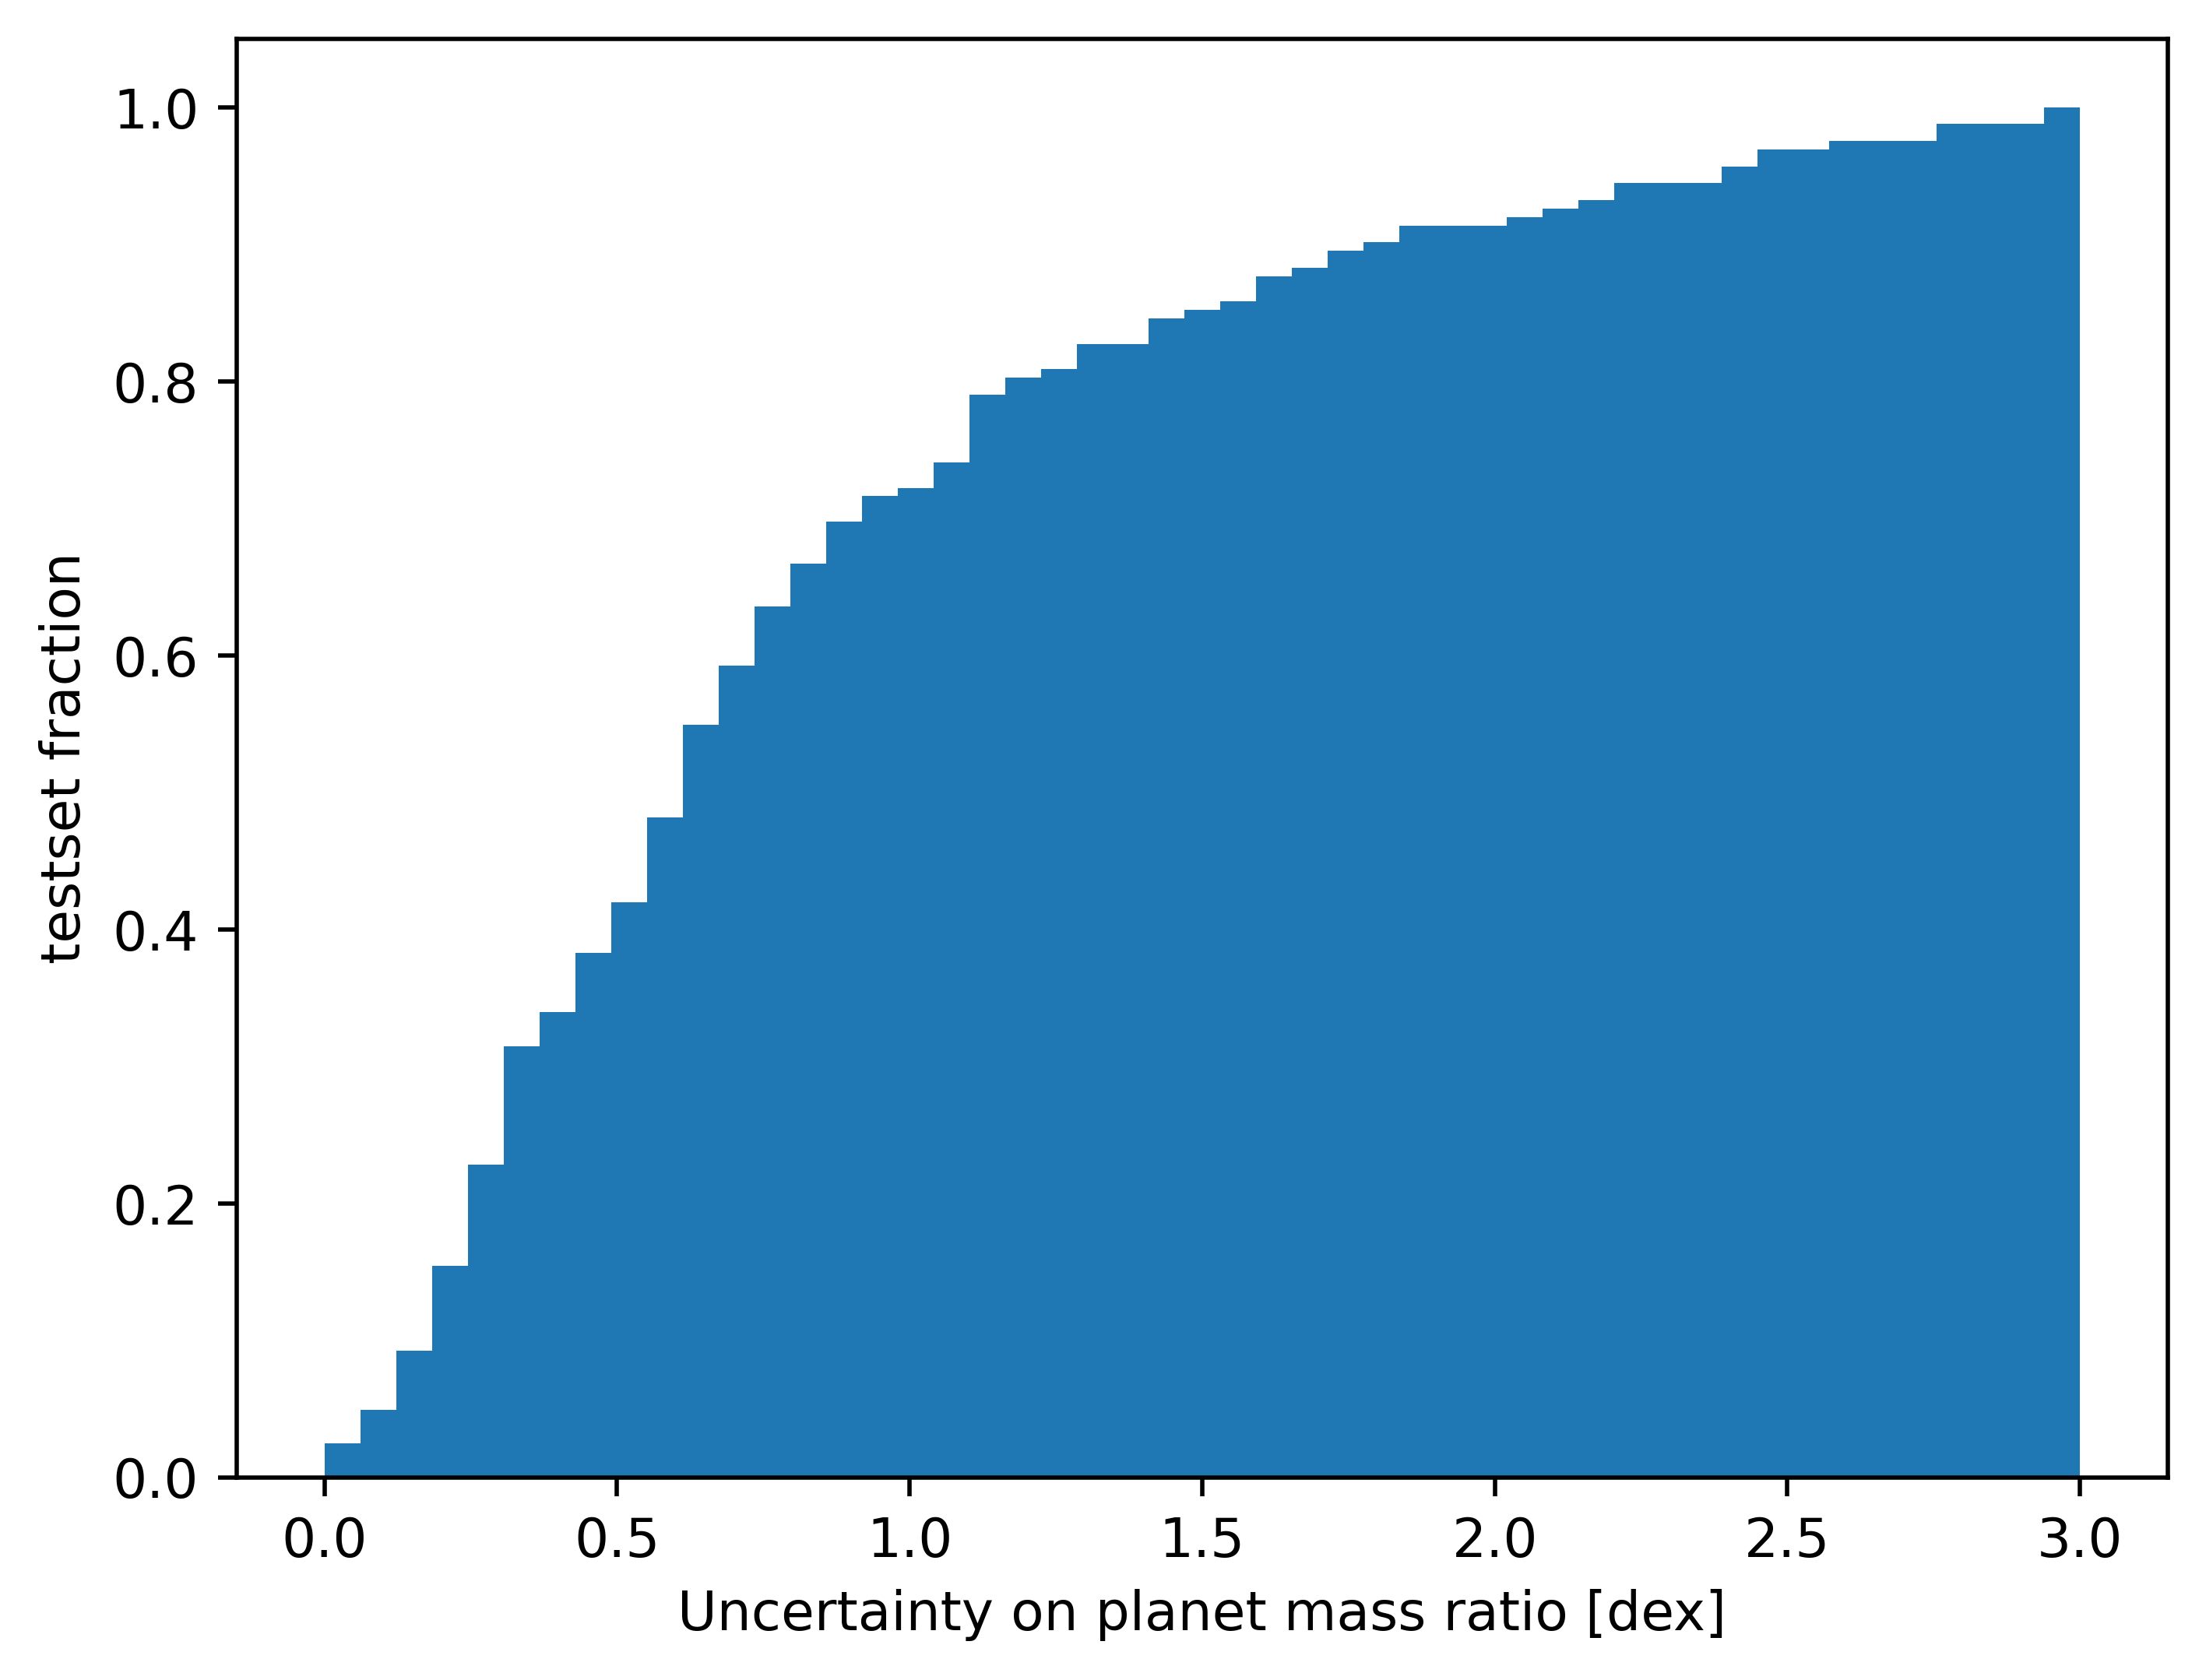

In [20]:
plt.hist(sigmas_right, np.linspace(0,3), cumulative=True, density=True)
plt.xlabel('Uncertainty on planet mass ratio [dex]')
plt.ylabel('testset fraction')
plt.gcf().set_dpi(500)

ValueError: x and y must be the same size

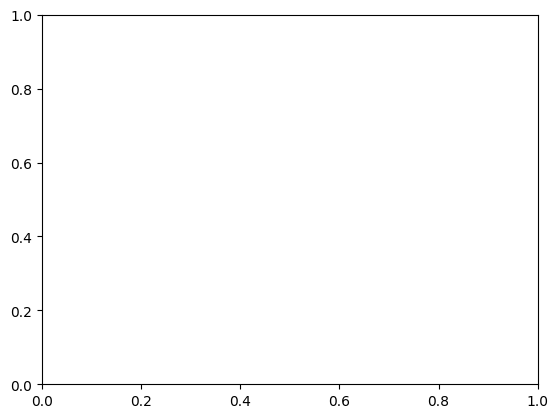

In [21]:
plt.scatter(testparams['Mth'][:-2], sigmas_right)
plt.xscale('log')
plt.ylim(0,3)

In [ ]:
plt.scatter(testparams['PlanetMass'][:-2], sigmas_right)
plt.xscale('log')
plt.ylim(0,3)

ValueError: x and y must be the same size

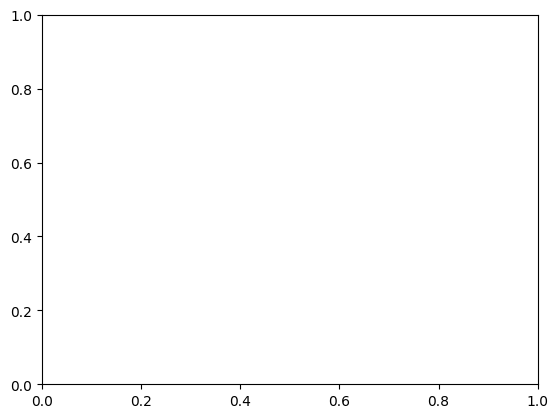

In [22]:
plt.scatter(testparams['Alpha'][:-2], sigmas_right)
plt.xscale('log')
plt.ylim(0,3)

In [23]:
sigmas_right = []
sigmas_left = []
sigmas = []

prop = 'AspectRatio'

for i in range(mses_cmaps[prop].shape[0]):
    mses = np.array(mses_cmaps[prop])[i, 0, :, :].sum(axis=-1)
    minimum = np.argmin(mses)
    N = np.min(mses)
    rm = minimum+1 if minimum<19 else 19
    lm = minimum-1 if minimum>0 else 0
    sigmas.append((1/((mses[rm]-2*mses[minimum]+mses[lm])/((-2+5)/20)**2/N))**0.5)
    if mses[rm] > mses[minimum]: 
        sigmas_right.append((1/((2*mses[rm]-2*mses[minimum])/((-2+5)/20)**2/N))**0.5)
    else:
        sigmas_right.append(np.log10(grids[prop][-1])-np.log10(grids[prop][minimum]))

    if mses[lm] > mses[minimum]:
        sigmas_left.append((1/((2*mses[lm]-2*mses[minimum])/((-2+5)/20)**2/N))**0.5)
    else:
        sigmas_left.append(-np.log10(grids[prop][0])+np.log10(grids[prop][minimum]))
        
sigmas = np.array(sigmas)
    #plt.scatter(np.log10(grids['PlanetMass'])-np.log10(testparams.iloc[i]['PlanetMass']), np.array(mse_varp_testset['PlanetMass'])[i, 0, :, 0])
    #plt.xscale('log')#plt.yscale('log')
mins = np.argmin(mses_cmaps['PlanetMass'][:, 0, :, :].mean(axis=-1), axis=1)
valmins = np.min(mses_cmaps['PlanetMass'][:, 0, :, :].mean(axis=-1), axis=1)


In [24]:
import gen_var_cmaps

     _  _                        _                    
  __| |(_) ___   ___  _ __ ___  (_) _ __    ___  _ __ 
 / _` || |/ __| / __|| '_ ` _ \ | || '_ \  / _ \| '__|
| (_| || |\__ \| (__ | | | | | || || | | ||  __/| |   
 \__,_||_||___/ \___||_| |_| |_||_||_| |_| \___||_|   
                                                      

*====================================================================================================*
Computing grid...
Grid maximum extent: 56847190866000.0
Grid step (cell size): 456603942698.79517
*====================================================================================================*
*====================================================================================================*
Computing grid...
Grid maximum extent: 56847190866000.0
Grid step (cell size): 456603942698.79517
*====================================================================================================*
Setting beam_info var to Beam: BMAJ=0.104 arcsec BMIN=0.094 a

In [205]:
cmaps = gen_var_cmaps.get_maps(212, 'PlanetMass')

*====================================================================================================*
Running prototype model with the following parameters:

{'height_lower': {'Rb': 0.03, 'p': 1.09, 'q': 4.18, 'z0': 19.91},
 'height_upper': {'Rb': 4.36, 'p': 1.21, 'q': 1.98, 'z0': 29.78},
 'intensity': {'I0': 0.3034, 'Rout': 380, 'p': -4.16, 'q': 3.68},
 'lineslope': {'Ls': 1.85, 'p': 0.21, 'q': 0.0},
 'linewidth': {'L0': 0.08, 'p': 0.86, 'q': -1.38},
 'orientation': {'PA': 0.7391469382195985,
                 'incl': 0.7977900010866079,
                 'xc': 0.0,
                 'yc': 0.0},
 'velocity': {'Mstar': 1.97,
              'R_p': 39045044252700.0,
              'alpha': np.float64(0.0044668359215096),
              'extrap_vfunc': <function nullv at 0x7ff6e556a8c0>,
              'flaringIndex': np.float64(0.0297499999999999),
              'h': np.float64(0.06955),
              'mask_only_ppos': False,
              'phi_p': 0.9948376736367678,
              'planetMass

In [207]:
np.save('cmaps_212Mp.npy', cmaps)

In [209]:
cmaps.shape

(20, 105, 250, 250)

In [222]:
cmaps = np.load('cmaps_212Mp.npy')

In [225]:
testset_cmaps = np.load('cmaps_from_simulations_testset_parfile_R261_phi0.99_hd163296like3corr.npy')[:-2]

In [227]:
testset_cmaps.shape

(231, 105, 250, 250)

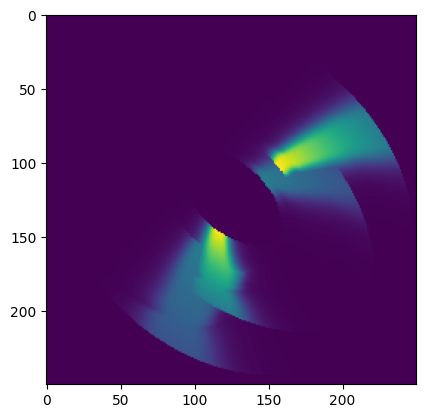

In [230]:
plt.imshow(testset_cmaps[212, 54])

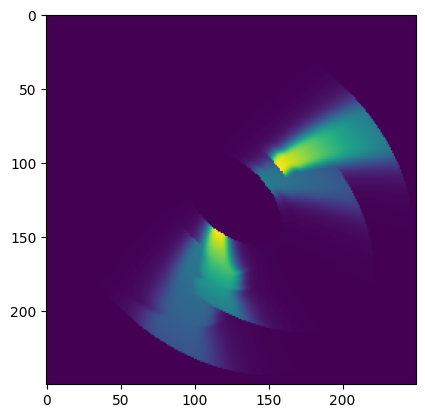

In [223]:
plt.imshow(cmaps[13, 54])

In [242]:
testset_cmaps.shape

(231, 105, 250, 250)

In [239]:
mse = ((testset_cmaps[212, :].reshape(1,-1,250,250)-cmaps[:, :])**2).mean(axis=(-1,-2))
#plt.scatter(range(20), mse)

In [244]:
np.argmax(mse[-1])

np.int64(49)

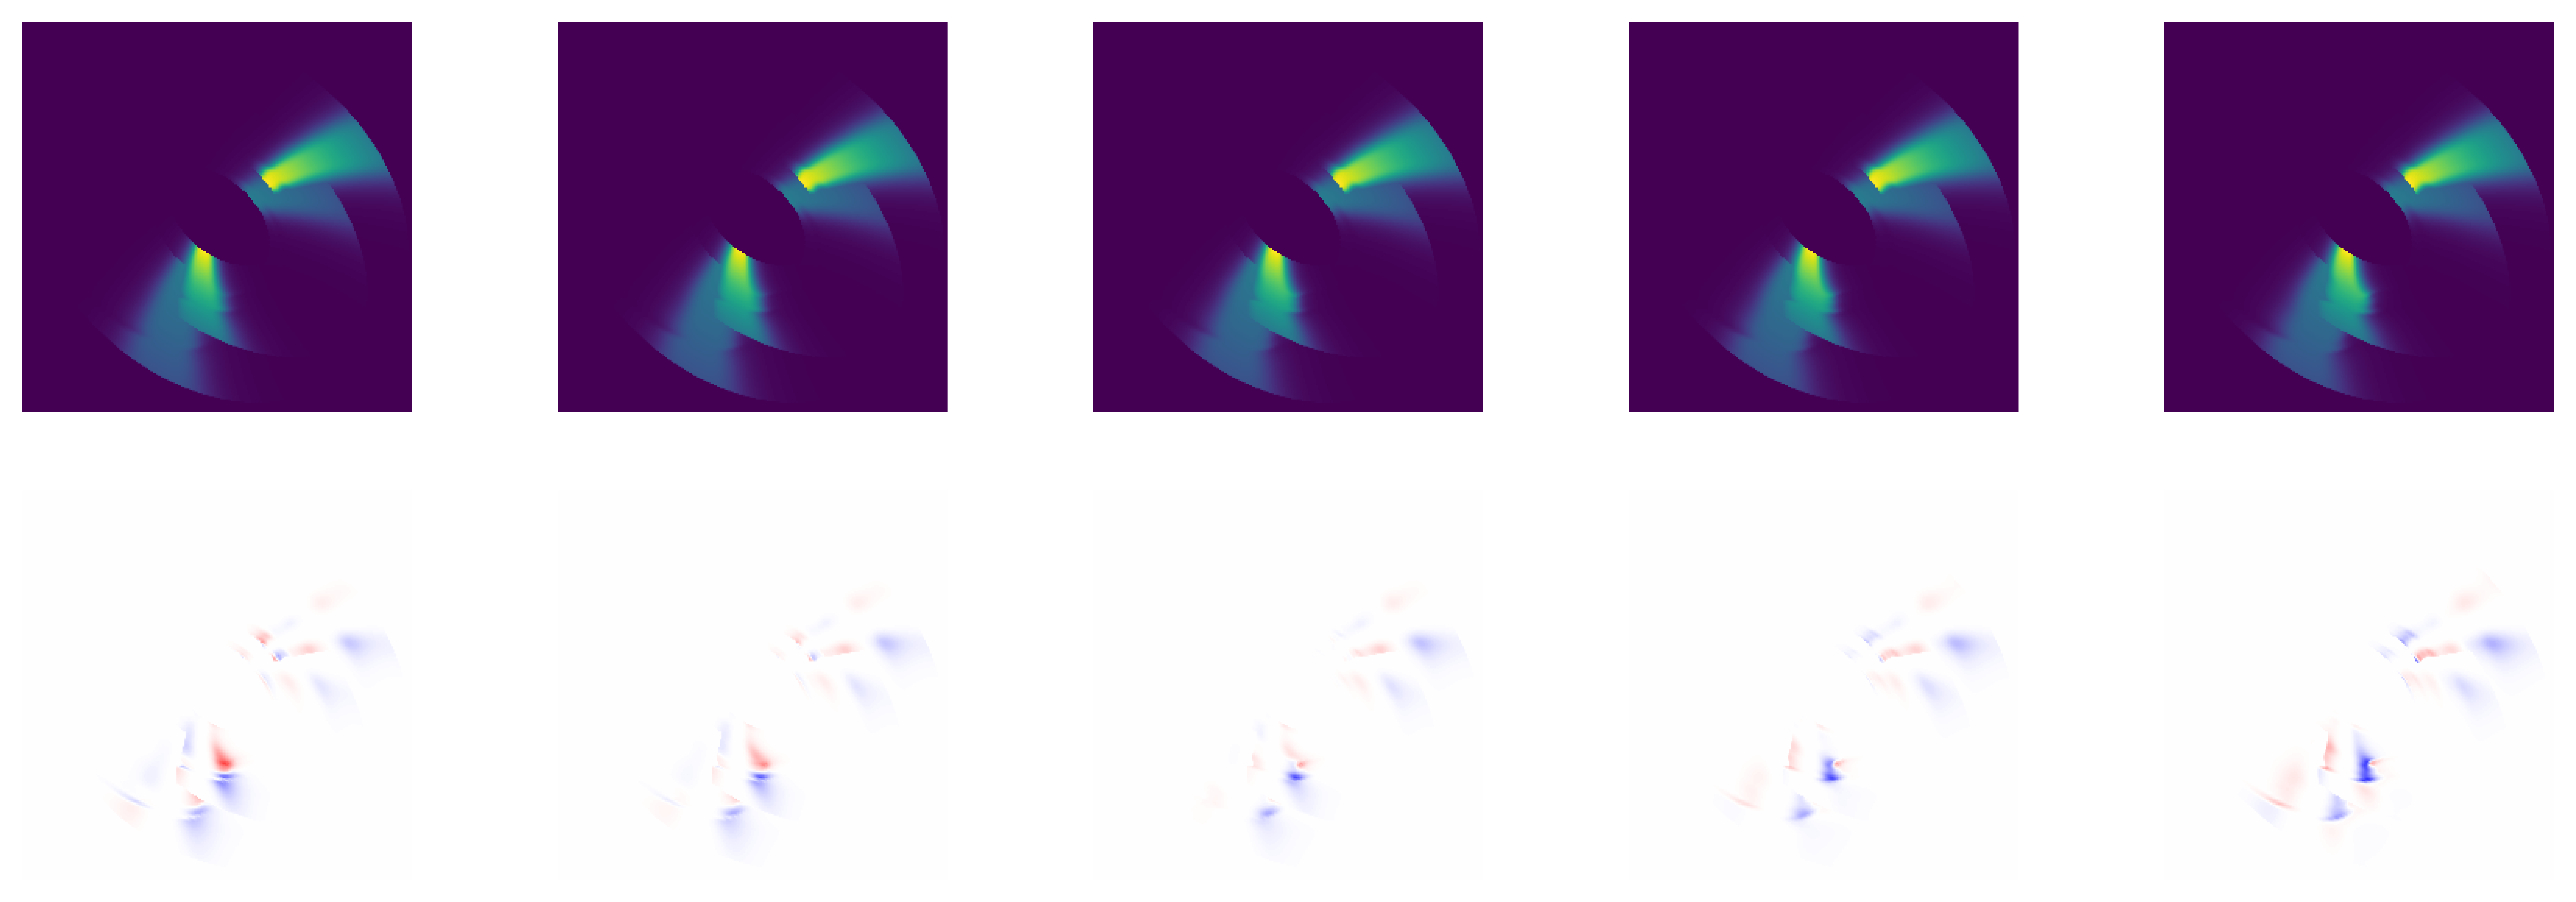

In [267]:
fig, axs = plt.subplots(2, 5, figsize=(15, 5))
vals = testset_cmaps[212,54].reshape(1,250,250)-cmaps[:, 54]
vv = np.percentile(np.abs(vals), 99.9)
vmin = -vv
vmax = vv
for j, i in enumerate(range(10,15)):
    axs[0, j].imshow(cmaps[i, 54])
    axs[1, j].imshow(testset_cmaps[212,54]-cmaps[i, 54], cmap='bwr', vmin=vmin, vmax=vmax)
    axs[0,j].axis('off')
    axs[1, j].axis('off')

plt.gcf().set_dpi(500)

In [21]:
import h5py

In [22]:
import h5py

f = h5py.File("cmaps_emulations_small.h5", "r", swmr=True)


In [23]:
f.keys()

<KeysViewHDF5 ['Alpha', 'AspectRatio', 'PlanetMass']>

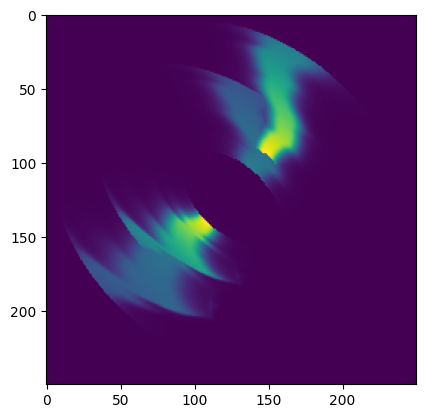

In [24]:
import matplotlib.pyplot as plt
plt.imshow(f['PlanetMass'][10,18,10])

In [30]:
f['PlanetMass'].refresh()

In [26]:
!ls -lh *.h5

-rw-r--r-- 1 alessandro.ruzza DiscEvol_storage 99G Mar  5 11:16 cmaps_emulations.h5
-rw-r--r-- 1 alessandro.ruzza DiscEvol_storage 38G Mar  6 10:32 cmaps_emulations_small.h5
-rw-r--r-- 1 alessandro.ruzza DiscEvol_storage 66G Mar  4 15:45 old_cmaps_eval.h5


In [27]:
f.keys()

<KeysViewHDF5 ['Alpha', 'AspectRatio', 'PlanetMass']>

In [28]:
import numpy as np
np.linspace(2.44, 9.16, 22)

array([2.44, 2.76, 3.08, 3.4 , 3.72, 4.04, 4.36, 4.68, 5.  , 5.32, 5.64,
       5.96, 6.28, 6.6 , 6.92, 7.24, 7.56, 7.88, 8.2 , 8.52, 8.84, 9.16])

In [31]:
np.array(f['PlanetMass']).sum(axis=(-1,-2,-3, -4))!=0

array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True, False, False, False, False, False,
       False, False,